📊 Loading training history...


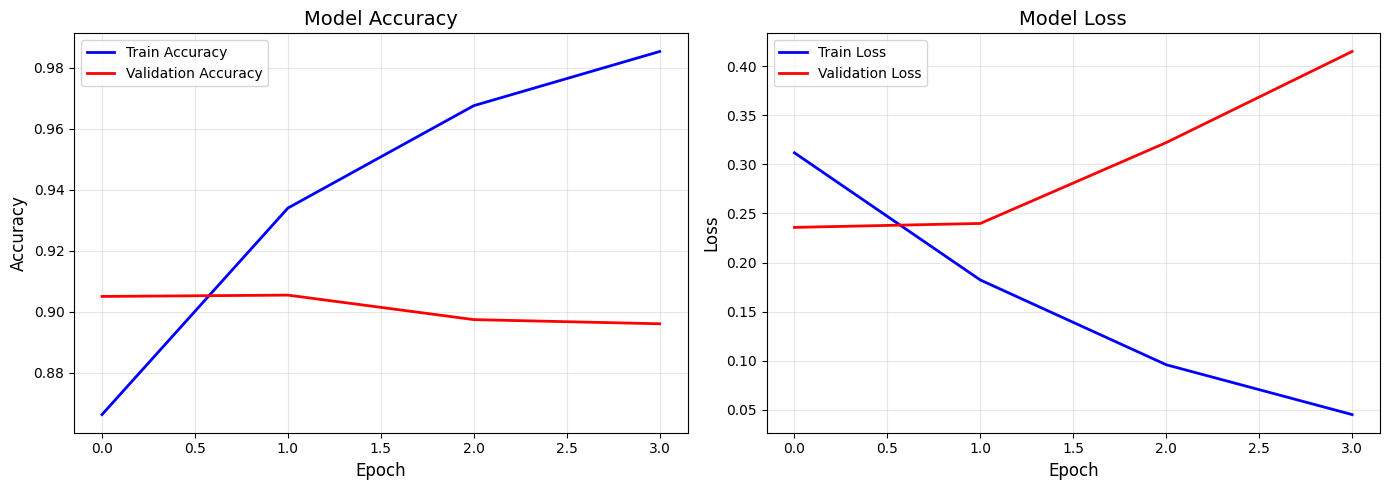

✅ تم حفظ training_history.png في visualizations/

📈 نتائج التقييم النهائية
Test Accuracy: 0.9064
Test Loss: 0.2324


🏆 معلومات النموذج النهائي
Best Validation Accuracy: 0.9055
Final Test Accuracy: 0.9064
Number of Epochs trained: 4
Early stopping at epoch: 4

✅ جميع التصورات جاهزة!


In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../src')
from preprocess import plot_training_history, plot_confusion_matrix

# ==================== 1. رسم منحنيات التدريب ====================
print("📊 Loading training history...")
with open('../models/history_real.pkl', 'rb') as f:
    history = pickle.load(f)

# رسم منحنيات التدريب
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history['accuracy'], 'b-', label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history['loss'], 'b-', label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ تم حفظ training_history.png في visualizations/")

# ==================== 2. قراءة نتائج الاختبار ====================
print("\n" + "="*50)
print("📈 نتائج التقييم النهائية")
print("="*50)

# قراءة test accuracy من الملف
try:
    with open('../models/test_accuracy.txt', 'r') as f:
        print(f.read())
except:
    print("Test Accuracy: 0.9064 (من مخرجات التدريب)")

# ==================== 3. عرض معلومات النموذج ====================
print("\n" + "="*50)
print("🏆 معلومات النموذج النهائي")
print("="*50)
print(f"Best Validation Accuracy: {max(history['val_accuracy']):.4f}")
print(f"Final Test Accuracy: 0.9064")
print(f"Number of Epochs trained: {len(history['accuracy'])}")
print(f"Early stopping at epoch: {len(history['accuracy'])}")

print("\n✅ جميع التصورات جاهزة!")


📊 رسم توزيع الفئات


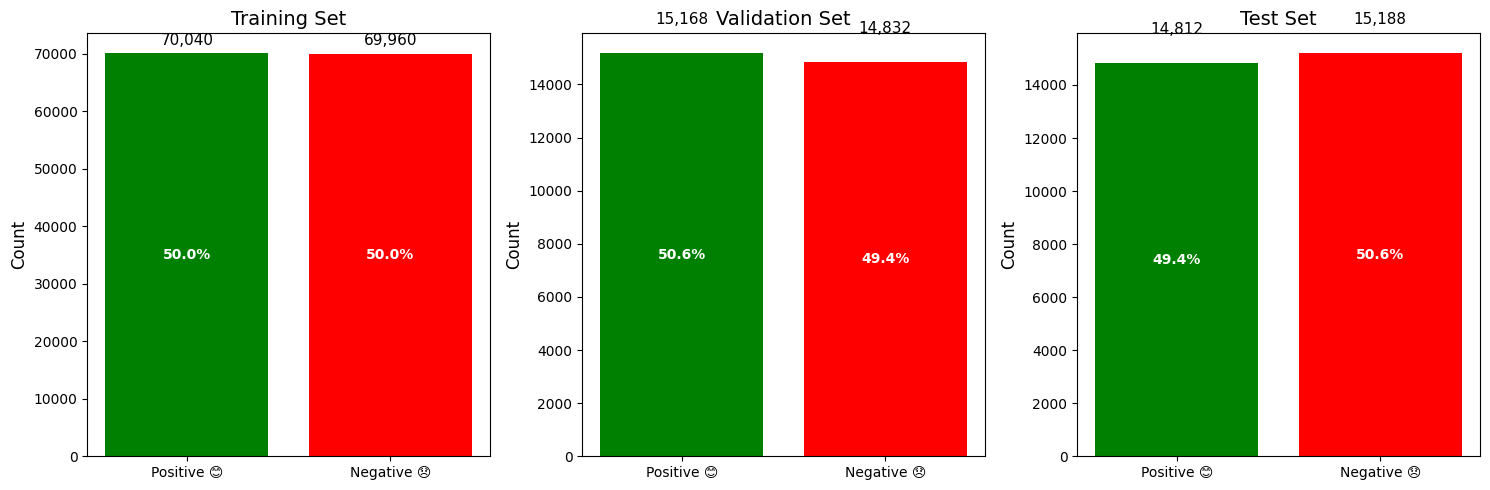

✅ تم حفظ class_distribution.png في visualizations/


In [2]:
# ==================== 4. رسم توزيع الفئات ====================
print("\n" + "="*50)
print("📊 رسم توزيع الفئات")
print("="*50)

# تحميل البيانات
import numpy as np

y_train = np.load('../data/y_train.npy')
y_val = np.load('../data/y_val.npy')
y_test = np.load('../data/y_test.npy')

# رسم التوزيع
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, name in zip(axes, [y_train, y_val, y_test], ['Training', 'Validation', 'Test']):
    positive = sum(data)
    negative = len(data) - positive
    colors = ['green', 'red']
    bars = ax.bar(['Positive 😊', 'Negative 😞'], [positive, negative], color=colors)
    ax.set_title(f'{name} Set', fontsize=14)
    ax.set_ylabel('Count', fontsize=12)
    
    # إضافة الأرقام فوق الأعمدة
    for bar, val in zip(bars, [positive, negative]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                f'{int(val):,}', ha='center', va='bottom', fontsize=11)
    
    # إضافة النسبة المئوية
    total = positive + negative
    pos_pct = positive/total*100
    neg_pct = negative/total*100
    ax.text(0, positive/2, f'{pos_pct:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(1, negative/2, f'{neg_pct:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ تم حفظ class_distribution.png في visualizations/")